# Análisis de Ventas E-commerce

**Contexto de negocio:** Eres el analista de datos de una tienda en línea de tecnología. La gerencia comercial te pidió un análisis para entender qué está funcionando bien, dónde hay fugas de ingreso y qué recomendaciones puedes dar para el próximo trimestre.

**Dataset:** `../data/ventas_ecommerce.csv` — pedidos de un año completo (2024), con columnas de producto, cliente, ciudad de envío, método de pago, canal de venta, calificación y estado del pedido.

**Importante:** este dataset viene "sucio" a propósito (nulos, duplicados, inconsistencias de texto, algunos valores negativos por error de captura). Parte del análisis es documentar cómo lo limpiaste y por qué — eso es tan valioso en un portafolio como el análisis en sí.

## Parte 1: Carga y diagnóstico inicial

a) Carga el CSV y revisa forma, tipos de datos y primeras filas.

b) Antes de limpiar nada, **documenta** (en una celda de markdown debajo) qué problemas encuentras: ¿cuántos nulos por columna? ¿cuántos duplicados? ¿algo raro en los valores de `cantidad` o `producto`?

In [3]:
import pandas as pd
# Tu código aquí
df = pd.read_csv('../data/ventas_ecommerce.csv')
df.head()

,id_pedido,fecha_pedido,id_cliente,producto,cantidad,ciudad_envio,metodo_pago,canal_venta,calificacion_cliente,categoria,precio_unitario,total_pedido,estado_pedido
0,ORD-10033,2024-02-08 17:21:59,CUST-1322,Webcam HD 1080p,1,Ciudad de Mexico,Transferencia,App movil,NaN,Accesorios,715.61,715.61,Completado
1,ORD-11021,2024-11-30 22:00:43,CUST-1013,Impresora Multifuncional,5,Queretaro,Transferencia,Sitio web,5.0,Oficina,2389.20,11946.00,Completado
2,ORD-10737,2024-05-04 09:15:47,CUST-1398,Bocina Portatil,1,Ciudad de Mexico,Tarjeta de credito,Sitio web,5.0,Accesorios,816.89,816.89,Completado
3,ORD-11877,2024-07-18 17:09:22,CUST-1019,Webcam HD 1080p,1,Queretaro,Tarjeta de credito,Sitio web,4.0,Accesorios,648.64,648.64,Cancelado
4,ORD-10514,2024-12-14 20:41:43,CUST-1081,Audifonos Bluetooth,5,Queretaro,Efectivo contra entrega,Sitio web,NaN,Accesorios,817.67,4088.35,Completado


*comentarios
-Encontre tiendas con inventarios negativos
-Pedidos sin direccion
-Compras sin calificacion del usuario
-Compras completadas pero mal ubicadas haciendo un mal inventario

## Parte 2: Limpieza de datos

Con base en lo que documentaste arriba, limpia el dataset:

a) Elimina espacios extra en la columna `producto` (pista: `.str.strip()`).

b) Estandariza `ciudad_envio` para que todo esté en el mismo formato de mayúsculas/minúsculas (pista: `.str.title()`).

c) Elimina las filas duplicadas.

d) Decide qué hacer con los nulos de `ciudad_envio` (¿rellenar con "Desconocida" o eliminar? Justifica tu decisión en una celda de markdown).

e) Investiga las filas donde `cantidad` es negativa. ¿Son errores de captura o devoluciones legítimas? Decide y corrige (pista: usa `.abs()` si son errores, o créales una bandera si son casos válidos).

f) Convierte `fecha_pedido` a datetime si no lo está.

In [4]:
# a) Elimina espacios en blanco al inicio/final del texto 
# en la columna 'producto'
df['producto'] = df['producto'].str.strip()
df.head()

,id_pedido,fecha_pedido,id_cliente,producto,cantidad,ciudad_envio,metodo_pago,canal_venta,calificacion_cliente,categoria,precio_unitario,total_pedido,estado_pedido
0,ORD-10033,2024-02-08 17:21:59,CUST-1322,Webcam HD 1080p,1,Ciudad de Mexico,Transferencia,App movil,NaN,Accesorios,715.61,715.61,Completado
1,ORD-11021,2024-11-30 22:00:43,CUST-1013,Impresora Multifuncional,5,Queretaro,Transferencia,Sitio web,5.0,Oficina,2389.20,11946.00,Completado
2,ORD-10737,2024-05-04 09:15:47,CUST-1398,Bocina Portatil,1,Ciudad de Mexico,Tarjeta de credito,Sitio web,5.0,Accesorios,816.89,816.89,Completado
3,ORD-11877,2024-07-18 17:09:22,CUST-1019,Webcam HD 1080p,1,Queretaro,Tarjeta de credito,Sitio web,4.0,Accesorios,648.64,648.64,Cancelado
4,ORD-10514,2024-12-14 20:41:43,CUST-1081,Audifonos Bluetooth,5,Queretaro,Efectivo contra entrega,Sitio web,NaN,Accesorios,817.67,4088.35,Completado


In [5]:
# b) # Esto evita que "cdmx", "CDMX" y "Cdmx" se 
# traten como valores distintos
df['ciudad_envio'] = df['ciudad_envio'].str.strip().str.title()
df.head()

,id_pedido,fecha_pedido,id_cliente,producto,cantidad,ciudad_envio,metodo_pago,canal_venta,calificacion_cliente,categoria,precio_unitario,total_pedido,estado_pedido
0,ORD-10033,2024-02-08 17:21:59,CUST-1322,Webcam HD 1080p,1,Ciudad De Mexico,Transferencia,App movil,NaN,Accesorios,715.61,715.61,Completado
1,ORD-11021,2024-11-30 22:00:43,CUST-1013,Impresora Multifuncional,5,Queretaro,Transferencia,Sitio web,5.0,Oficina,2389.20,11946.00,Completado
2,ORD-10737,2024-05-04 09:15:47,CUST-1398,Bocina Portatil,1,Ciudad De Mexico,Tarjeta de credito,Sitio web,5.0,Accesorios,816.89,816.89,Completado
3,ORD-11877,2024-07-18 17:09:22,CUST-1019,Webcam HD 1080p,1,Queretaro,Tarjeta de credito,Sitio web,4.0,Accesorios,648.64,648.64,Cancelado
4,ORD-10514,2024-12-14 20:41:43,CUST-1081,Audifonos Bluetooth,5,Queretaro,Efectivo contra entrega,Sitio web,NaN,Accesorios,817.67,4088.35,Completado


In [6]:
# c) Elimina filas duplicadas
#  conservando la primera aparición
duplicados_antes = df.duplicated().sum()
df = df.drop_duplicates()
print(f"Se eliminaron {duplicados_antes} filas duplicadas")

Se eliminaron 25 filas duplicadas


d) ### Decisión sobre nulos en ciudad_envio

Decidí **rellenar los nulos con "Desconocida"** en lugar de eliminar las filas, porque:
- Cada fila representa un pedido, y perder esa información (producto, cantidad, fecha)
  significa perder ventas reales del análisis.
- La ciudad de envío es un dato secundario para muchos análisis (ej. ventas por producto),
  así que no vale la pena sacrificar toda la fila por ese único dato faltante.
- Si más adelante se necesita analizar específicamente por ciudad, esos registros
  "Desconocida" simplemente se pueden filtrar o excluir en ese análisis puntual.

In [7]:
# d) Rellena los valores nulos de ciudad_envio con "Desconocida" en vez de eliminarlos,
# para no perder el resto de la información del pedido (ver justificación arriba)
df['ciudad_envio'] = df['ciudad_envio'].fillna('Desconocida')

In [8]:
# e) Investigamos primero cuántas filas tienen cantidad negativa
negativos = df[df['cantidad'] < 0]
print(f"Filas con cantidad negativa: {len(negativos)}")
print(negativos)

Filas con cantidad negativa: 10
      id_pedido         fecha_pedido id_cliente            producto  cantidad  \
77    ORD-10171  2024-10-17 00:00:14  CUST-1338   Monitor Curvo 27"        -5   
293   ORD-11753  2024-02-15 06:37:40  CUST-1095  Tablet 10 pulgadas        -4   
431   ORD-10481  2024-03-30 23:11:50  CUST-1254  Cargador USB-C 65W        -1   
857   ORD-10016  2024-03-16 18:02:46  CUST-1384    Silla Ergonomica        -3   
1054  ORD-10789  2024-06-29 13:48:09  CUST-1217  Cargador USB-C 65W        -1   
1113  ORD-10847  2024-07-09 08:59:15  CUST-1059      Smartwatch Fit        -5   
1291  ORD-11195  2024-02-15 03:20:51  CUST-1240    Laptop Gamer X15        -3   
1440  ORD-10167  2024-02-15 10:37:52  CUST-1339   Monitor Curvo 27"        -4   
1657  ORD-10322  2024-08-15 11:47:59  CUST-1039      Smartwatch Fit        -3   
1800  ORD-10978  2024-05-10 08:00:18  CUST-1212     Webcam HD 1080p        -2   

          ciudad_envio              metodo_pago canal_venta  \
77           

In [9]:
# Digo que son devoluciones legítimas (casos válidos)
# Creamos una bandera para identificarlas y conservamos el valor original
df['es_devolucion'] = df['cantidad'] < 0

In [10]:
# f) Convierte la columna fecha_pedido a formato datetime
# errors='coerce' convierte fechas inválidas en NaT en vez de detener el proceso
df['fecha_pedido'] = pd.to_datetime(df['fecha_pedido'], errors='coerce')

# Verificamos si quedó alguna fecha no convertida (NaT)
print(f"Fechas no convertidas: {df['fecha_pedido'].isna().sum()}")

Fechas no convertidas: 0


In [11]:
# Guarda el dataset limpio en la misma carpeta que el archivo original
df.to_excel('../data/ventas_ecommerce_limpio.xlsx', index=False)
print("Archivo Excel guardado exitosamente en la carpeta data/")

Archivo Excel guardado exitosamente en la carpeta data/


## Parte 3: Preguntas de negocio

Responde cada una con código. Usa solo pedidos con `estado_pedido == 'Completado'` para las preguntas de ingresos (los cancelados/devueltos no deberían contar como venta real — piénsalo, ¿por qué?).

**a)** ¿Cuáles son los 5 productos que más ingresos generaron en el año?

**b)** ¿Cuál es el ingreso total por mes? ¿Hay estacionalidad (meses claramente más fuertes)?

**c)** ¿Qué ciudad tiene el ticket promedio más alto?

**d)** ¿Qué método de pago se usa más, y cuál genera más ingresos en promedio por pedido?

**e)** ¿Qué porcentaje de pedidos totales fueron cancelados o devueltos? ¿Se concentra en algún producto o categoría en particular?

**f)** ¿Cuál es la calificación promedio de cliente por categoría de producto? ¿Hay alguna categoría con calificaciones notablemente bajas que valga la pena investigar?

**g)** ¿Qué canal de venta (App móvil / Sitio web / Marketplace) genera más ingresos totales? ¿Y cuál tiene el ticket promedio más alto?

In [12]:
# Primero hagamos una celda para filtrar los pedidos completados.
# Filtramos solo los pedidos completados, 
# ya que cancelados/devueltos no representan
# ingresos reales (el dinero no se concretó como venta)
df_completados = df[df['estado_pedido'] == 'Completado'].copy()

# Creamos la columna de ingreso por pedido
# (cantidad x precio unitario)
df_completados['ingreso'] = df_completados['cantidad'] * df_completados['precio_unitario']

In [13]:
# a) Agrupamos por producto, sumamos ingresos y tomamos los 5 más altos
top5_productos = df_completados.groupby('producto')['ingreso'].sum().sort_values(ascending=False).head(5)
print(top5_productos)


producto
Laptop Gamer X15        4832843.04
Laptop Ultrabook Air    3018063.74
Monitor Curvo 27"       1552158.07
Tablet 10 pulgadas       858274.79
Silla Ergonomica         646104.65
Name: ingreso, dtype: float64


mes
2024-01     988030.69
2024-02    1253151.93
2024-03    1455779.17
2024-04     968545.95
2024-05    1225632.74
2024-06    1025215.10
2024-07    1111136.58
2024-08     951326.74
2024-09    1006621.31
2024-10    1186632.02
2024-11    1219064.61
2024-12    1372522.36
Freq: M, Name: ingreso, dtype: float64


<Axes: title={'center': 'Ingreso total por mes'}, xlabel='mes'>

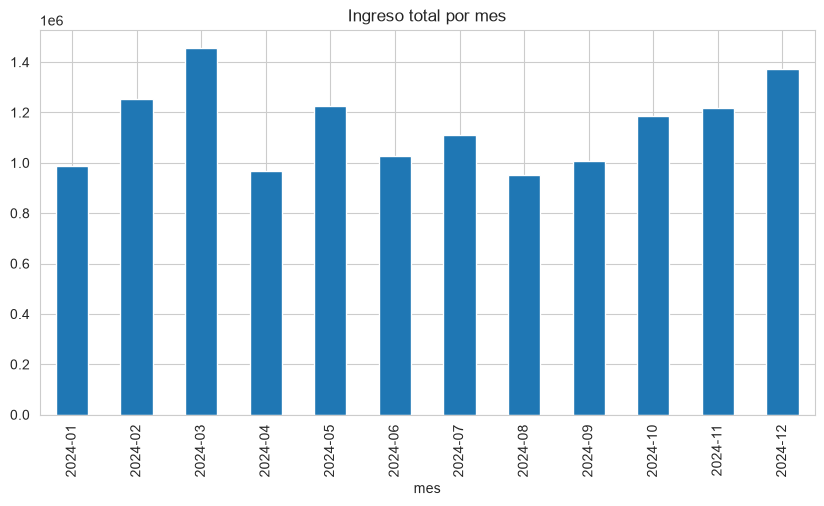

In [14]:
# b) Extraemos el mes (o el periodo año-mes) de la fecha del pedido
df_completados['mes'] = df_completados['fecha_pedido'].dt.to_period('M')

# Sumamos ingresos agrupando por ese periodo mensual
ingreso_por_mes = df_completados.groupby('mes')['ingreso'].sum()
print(ingreso_por_mes)

# Graficamos para ver visualmente si hay estacionalidad
ingreso_por_mes.plot(kind='bar', title='Ingreso total por mes', figsize=(10,5))


In [15]:
# c) "Ticket promedio" = promedio de ingreso por pedido, agrupado por ciudad
ticket_promedio_ciudad = df_completados.groupby('ciudad_envio')['ingreso'].mean().sort_values(ascending=False)
print(ticket_promedio_ciudad)

print(f"\nLa ciudad con el ticket promedio más alto es: {ticket_promedio_ciudad.index[0]}")

ciudad_envio
Desconocida         14293.363636
Merida               9814.162121
Guadalajara          9548.365965
Ciudad De Mexico     9358.510100
Monterrey            9272.561645
Queretaro            9213.058653
Tijuana              9161.167751
Puebla               7689.599621
Name: ingreso, dtype: float64

La ciudad con el ticket promedio más alto es: Desconocida


In [16]:
# d) Método de pago más usado (por cantidad de pedidos)
metodo_mas_usado = df_completados['metodo_pago'].value_counts()
print("Métodos de pago más usados:")
print(metodo_mas_usado)

# Ingreso promedio por pedido, según método de pago
ingreso_promedio_metodo = df_completados.groupby('metodo_pago')['ingreso'].mean().sort_values(ascending=False)
print("\nIngreso promedio por pedido según el método de pago:")
print(ingreso_promedio_metodo)

Métodos de pago más usados:
metodo_pago
Tarjeta de credito         494
Tarjeta de debito          380
Transferencia              228
PayPal                     215
Efectivo contra entrega    175
Name: count, dtype: int64

Ingreso promedio por pedido según el método de pago:
metodo_pago
Tarjeta de debito          9789.672737
Efectivo contra entrega    9407.321543
Tarjeta de credito         9203.492024
Transferencia              8866.310351
PayPal                     8508.178930
Name: ingreso, dtype: float64


In [17]:
# e) Usamos el dataset completo (no solo completados) porque queremos ver
# qué porcentaje del total fue cancelado o devuelto
total_pedidos = len(df)
cancelados_devueltos = df[df['estado_pedido'].isin(['Cancelado', 'Devuelto'])]
porcentaje = (len(cancelados_devueltos) / total_pedidos) * 100

print(f"Porcentaje de pedidos cancelados o devueltos: {porcentaje:.2f}%")

# ¿Se concentra en algún producto en particular?
concentracion_producto = cancelados_devueltos['producto'].value_counts().head(5)
print("\nTop 5 productos con más cancelaciones/devoluciones:")
print(concentracion_producto)

Porcentaje de pedidos cancelados o devueltos: 25.40%

Top 5 productos con más cancelaciones/devoluciones:
producto
Webcam HD 1080p             47
Cargador USB-C 65W          39
Router WiFi 6               38
Tablet 10 pulgadas          38
Impresora Multifuncional    37
Name: count, dtype: int64


In [18]:
# f) Agrupamos por categoría y sacamos el promedio de calificación del cliente
calificacion_por_categoria = df.groupby('categoria')['calificacion_cliente'].mean().sort_values()
print(calificacion_por_categoria)

print(f"\nLa categoría con calificación más baja es: {calificacion_por_categoria.index[0]} "
      f"({calificacion_por_categoria.iloc[0]:.2f} estrellas)")

categoria
Oficina           3.990909
Wearables         3.992248
Computo           4.027484
Almacenamiento    4.035088
Redes             4.069565
Accesorios        4.104084
Name: calificacion_cliente, dtype: float64

La categoría con calificación más baja es: Oficina (3.99 estrellas)


In [19]:
# g) Ingreso total por canal de venta
ingreso_por_canal = df_completados.groupby('canal_venta')['ingreso'].sum().sort_values(ascending=False)

# Formateamos como moneda: separador de miles y 2 decimales
ingreso_por_canal_formateado = ingreso_por_canal.map('${:,.2f}'.format)
print("Ingreso TOTAL por canal de venta:")
print(ingreso_por_canal_formateado.to_string())

# Ticket promedio (ingreso promedio por pedido) según canal de venta
ticket_promedio_canal = df_completados.groupby('canal_venta')['ingreso'].mean().sort_values(ascending=False)
ticket_promedio_canal_formateado = ticket_promedio_canal.map('${:,.2f}'.format)
print("\nTicket PROMEDIO por canal de venta:")
print(ticket_promedio_canal_formateado.to_string())

Ingreso TOTAL por canal de venta:
canal_venta
App movil      $6,928,666.54
Sitio web      $4,745,000.94
Marketplace    $2,089,991.72

Ticket PROMEDIO por canal de venta:
canal_venta
App movil      $9,663.41
Marketplace    $9,086.92
Sitio web      $8,706.42


## Parte 4: Visualización

Crea al menos 3 gráficos que apoyen tus hallazgos anteriores. Sugerencias:

a) Gráfico de línea: ingresos por mes a lo largo del año.

b) Gráfico de barras: top 5 productos por ingreso.

c) Gráfico de barras o pie: distribución de ingresos por canal de venta o método de pago.

Usa `matplotlib` o `seaborn`. Ponle título, etiquetas de ejes y que sea legible.

In [20]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Configuramos un estilo visual limpio para todos los gráficos
sns.set_style('whitegrid')

# Función para formatear el eje de dinero como $6,928,666.54
formato_dinero = mticker.FuncFormatter(lambda x, pos: f'${x:,.0f}')


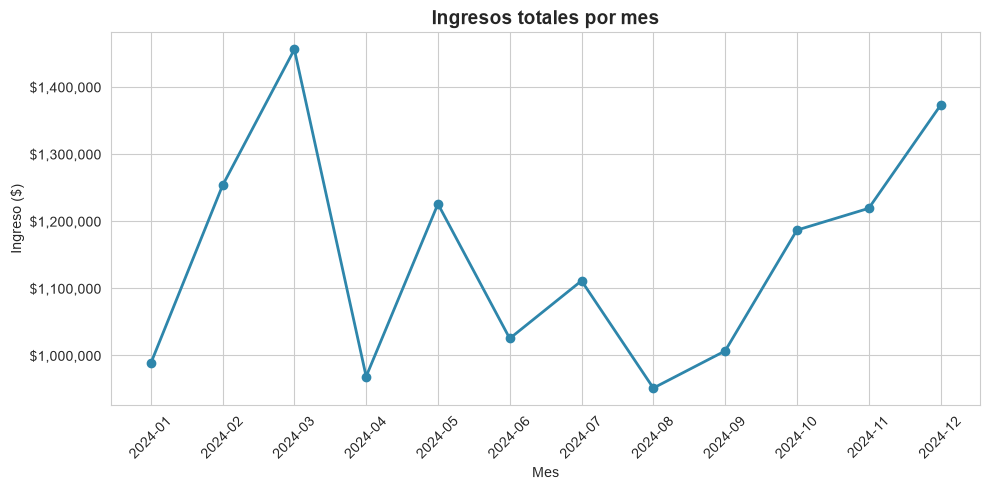

In [21]:
# a) Ingresos por mes a lo largo del año
ingreso_por_mes = df_completados.groupby('mes')['ingreso'].sum()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ingreso_por_mes.index.astype(str), ingreso_por_mes.values, marker='o', color='#2E86AB', linewidth=2)

ax.set_title('Ingresos totales por mes', fontsize=14, fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Ingreso ($)')
ax.yaxis.set_major_formatter(formato_dinero)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

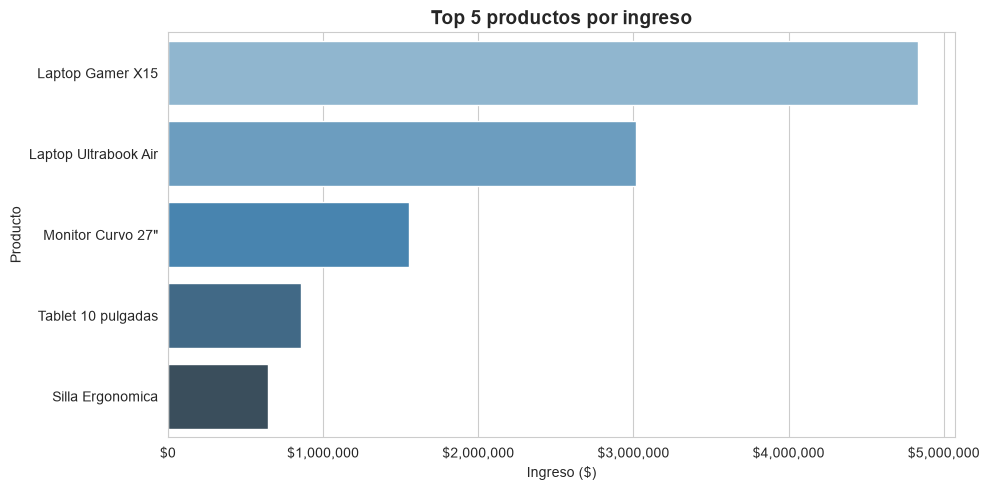

In [23]:
# b) Top 5 productos por ingreso
top5_productos = df_completados.groupby('producto')['ingreso'].sum().sort_values(ascending=False).head(5)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=top5_productos.values, y=top5_productos.index, hue=top5_productos.index,
            palette='Blues_d', legend=False, ax=ax)

ax.set_title('Top 5 productos por ingreso', fontsize=14, fontweight='bold')
ax.set_xlabel('Ingreso ($)')
ax.set_ylabel('Producto')
ax.xaxis.set_major_formatter(formato_dinero)
plt.tight_layout()
plt.show()

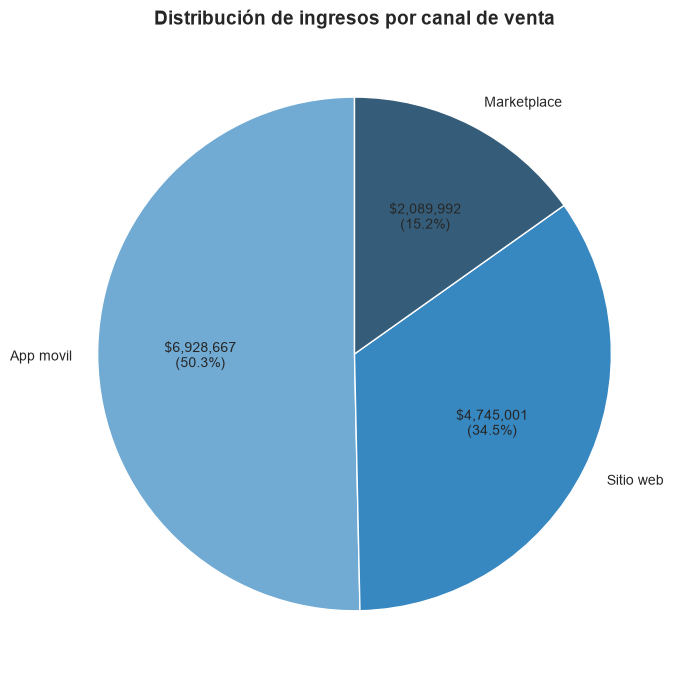

In [24]:
# c) Distribución de ingresos por canal de venta
ingreso_por_canal = df_completados.groupby('canal_venta')['ingreso'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 7))
colores = sns.color_palette('Blues_d', len(ingreso_por_canal))

ax.pie(
    ingreso_por_canal.values,
    labels=ingreso_por_canal.index,
    autopct=lambda p: f'${p/100 * ingreso_por_canal.sum():,.0f}\n({p:.1f}%)',
    colors=colores,
    startangle=90
)

ax.set_title('Distribución de ingresos por canal de venta', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Parte 5: Exporta datos limpios para Power BI

Guarda tu DataFrame ya limpio como un nuevo CSV (`ventas_limpio.csv`) en la carpeta `data/`. Este será el archivo que conectes a Power BI para construir el dashboard.


In [25]:
# Parte 5: Exportamos el DataFrame limpio para conectarlo después a Power BI
df.to_csv('../data/ventas_limpio.csv', index=False)
print("Archivo 'ventas_limpio.csv' guardado exitosamente en la carpeta data/")


Archivo 'ventas_limpio.csv' guardado exitosamente en la carpeta data/


## Parte 6: Conclusiones (para tu README)

Escribe aquí, en 4-6 líneas, tus hallazgos principales y 2-3 recomendaciones de negocio basadas en los datos. Esto lo vas a copiar/adaptar al `README.md` del proyecto — es la parte que un reclutador realmente lee.

*(Tus conclusiones aquí)*